In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
from pathlib import Path

print("Python is running from:")
print(Path.cwd())

print("\nFiles/folders here:")
print(list(Path.cwd().iterdir()))

Python is running from:
c:\Users\imsan\OneDrive\Desktop\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis\notebooks

Files/folders here:
[WindowsPath('c:/Users/imsan/OneDrive/Desktop/SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis/notebooks/01_EDA.ipynb')]


In [12]:
from pathlib import Path

print("Current folder:")
print(Path.cwd())

print("\nParent folder:")
print(Path.cwd().parent)

print("\nFiles in parent folder:")
for item in Path.cwd().parent.iterdir():
    print(item)

print("\nCSV files found:")
for item in Path.cwd().parent.rglob("*.csv"):
    print(item)

Current folder:
c:\Users\imsan\OneDrive\Desktop\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis\notebooks

Parent folder:
c:\Users\imsan\OneDrive\Desktop\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis

Files in parent folder:
c:\Users\imsan\OneDrive\Desktop\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis\.git
c:\Users\imsan\OneDrive\Desktop\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis\Data
c:\Users\imsan\OneDrive\Desktop\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis\notebooks
c:\Users\imsan\OneDrive\Desktop\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis\README.md

CSV files found:
c:\Users\imsan\OneDrive\Desktop\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis\Data\Ecommerce_Dataset .csv


In [14]:
# Load the dataset
df = pd.read_csv("../Data/Ecommerce_Dataset .csv")

# Display the first 5 rows
df.head()

C:\Users\imsan\AppData\Local\Temp\ipykernel_18100\2996283270.py:2: DtypeWarning: Columns (0: order_id, 1: customer_id, 2: transaction_date, 3: product_category, 4: signup_date, 5: acquisition_channel, 6: country) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../Data/Ecommerce_Dataset .csv")


,order_id,customer_id,transaction_date,product_category,quantity,unit_price,revenue,signup_date,acquisition_channel,country
0,ORD0000001,CUST000001,24/05/2023,Fashion,4.0,144.98,579.92,13/04/2023,Instagram,Canada
1,ORD0000002,CUST000002,18/03/2024,Beauty,3.0,28.21,84.63,11/3/2024,Email,USA
2,ORD0000003,CUST000002,9/4/2024,Beauty,4.0,24.68,98.72,11/3/2024,Email,USA
3,ORD0000004,CUST000002,5/5/2024,Fashion,2.0,35.77,71.54,11/3/2024,Email,USA
4,ORD0000005,CUST000002,20/06/2024,Sports,2.0,19.67,39.34,11/3/2024,Email,USA


In [16]:
# Check dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 143545
Number of columns: 10


In [ ]:
print(df.columns.tolist())

['order_id', 'customer_id', 'transaction_date', 'product_category', 'quantity', 'unit_price', 'revenue', 'signup_date', 'acquisition_channel', 'country']


In [20]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 143545 entries, 0 to 143544
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             71772 non-null  str    
 1   customer_id          71772 non-null  str    
 2   transaction_date     71772 non-null  str    
 3   product_category     71772 non-null  str    
 4   quantity             71772 non-null  float64
 5   unit_price           71772 non-null  float64
 6   revenue              71772 non-null  float64
 7   signup_date          71772 non-null  str    
 8   acquisition_channel  71772 non-null  str    
 9   country              71772 non-null  str    
dtypes: float64(3), str(7)
memory usage: 11.0 MB


In [21]:
missing_values = df.isnull().sum()

print(missing_values)

order_id               71773
customer_id            71773
transaction_date       71773
product_category       71773
quantity               71773
unit_price             71773
revenue                71773
signup_date            71773
acquisition_channel    71773
country                71773
dtype: int64


In [23]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 71772


In [24]:
# Basic statistical summary

df.describe()

,quantity,unit_price,revenue
count,71772.000000,71772.000000,71772.000000
mean,2.500543,129.780982,324.114706
std,1.118278,69.358783,238.430900
min,1.000000,10.000000,10.000000
25%,2.000000,69.357500,134.310000
50%,2.000000,129.580000,248.285000
75%,4.000000,189.610000,469.920000
max,4.000000,249.990000,999.960000


In [25]:
# Convert date columns to datetime format

df["transaction_date"] = pd.to_datetime(df["transaction_date"], dayfirst=True)
df["signup_date"] = pd.to_datetime(df["signup_date"], dayfirst=True)

print("Date columns converted successfully!")

Date columns converted successfully!


In [26]:
# Check date ranges

print("Transaction date range:")
print(df["transaction_date"].min(), "to", df["transaction_date"].max())

print("\nSignup date range:")
print(df["signup_date"].min(), "to", df["signup_date"].max())

Transaction date range:
2023-01-09 00:00:00 to 2024-12-31 00:00:00

Signup date range:
2023-01-01 00:00:00 to 2024-12-20 00:00:00


In [27]:
# Check numeric columns

print("Quantity statistics:")
print(df["quantity"].describe())

print("\nRevenue statistics:")
print(df["revenue"].describe())

Quantity statistics:
count    71772.000000
mean         2.500543
std          1.118278
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max          4.000000
Name: quantity, dtype: float64

Revenue statistics:
count    71772.000000
mean       324.114706
std        238.430900
min         10.000000
25%        134.310000
50%        248.285000
75%        469.920000
max        999.960000
Name: revenue, dtype: float64


In [28]:
# Check unique categories

print("Product Categories:")
print(df["product_category"].unique())

print("\nAcquisition Channels:")
print(df["acquisition_channel"].unique())

print("\nCountries:")
print(df["country"].unique())

Product Categories:
<StringArray>
['Fashion', 'Beauty', 'Sports', 'Electronics', 'Books', 'Home', nan]
Length: 7, dtype: str

Acquisition Channels:
<StringArray>
[     'Instagram',          'Email',   'Facebook Ads',       'Referral',
 'Organic Search',     'Google Ads',         'Direct',              nan]
Length: 8, dtype: str

Countries:
<StringArray>
['Canada', 'USA', 'France', 'Germany', 'UK', 'Australia', nan]
Length: 7, dtype: str


In [29]:
# Check revenue calculation

df["calculated_revenue"] = df["quantity"] * df["unit_price"]

df["revenue_difference"] = (
    df["revenue"] - df["calculated_revenue"]
)

print("Rows where revenue calculation differs:")
print((df["revenue_difference"].abs() > 0.01).sum())

Rows where revenue calculation differs:
0


In [30]:
# Customer-level analysis

customer_summary = df.groupby("customer_id").agg(
    total_orders=("order_id", "nunique"),
    total_revenue=("revenue", "sum"),
    first_purchase=("transaction_date", "min"),
    last_purchase=("transaction_date", "max")
).reset_index()

customer_summary.head()

,customer_id,total_orders,total_revenue,first_purchase,last_purchase
0,CUST000001,1,579.92,2023-05-24,2023-05-24
1,CUST000002,7,1472.17,2024-03-18,2024-10-12
2,CUST000003,1,359.76,2023-10-21,2023-10-21
3,CUST000004,8,1633.92,2023-04-25,2023-12-04
4,CUST000005,2,209.94,2023-04-13,2023-06-02


In [31]:
# Number of unique customers

print("Total unique customers:", df["customer_id"].nunique())
print("Total orders:", df["order_id"].nunique())
print("Total transactions:", len(df))

Total unique customers: 19076
Total orders: 71772
Total transactions: 143545


In [32]:
# Revenue by product category

category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

product_category
Beauty         3912872.63
Fashion        3904194.37
Electronics    3899348.15
Sports         3885545.85
Home           3862262.52
Books          3798137.14
Name: revenue, dtype: float64

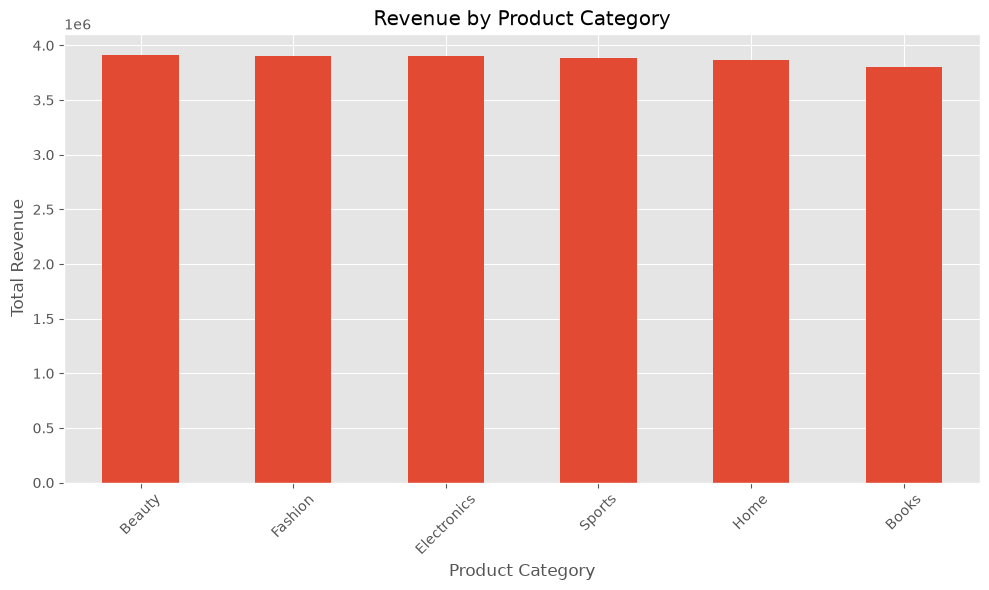

In [33]:
# Revenue by product category

plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [34]:
# Monthly revenue trend

monthly_revenue = (
    df.groupby(df["transaction_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue

transaction_date
2023-01      62019.30
2023-02     215872.14
2023-03     464734.56
2023-04     569963.50
2023-05     738752.96
2023-06     800565.04
2023-07     899620.27
2023-08     969400.18
2023-09    1034642.50
2023-10    1070867.20
2023-11    1081962.05
2023-12    1097224.36
2024-01    1158996.74
2024-02    1105814.47
2024-03    1156231.11
2024-04    1157465.40
2024-05    1196574.65
2024-06    1159232.62
2024-07    1237700.80
2024-08    1199497.48
2024-09    1156805.50
2024-10    1274419.45
2024-11    1213895.28
2024-12    1240103.10
Freq: M, Name: revenue, dtype: float64

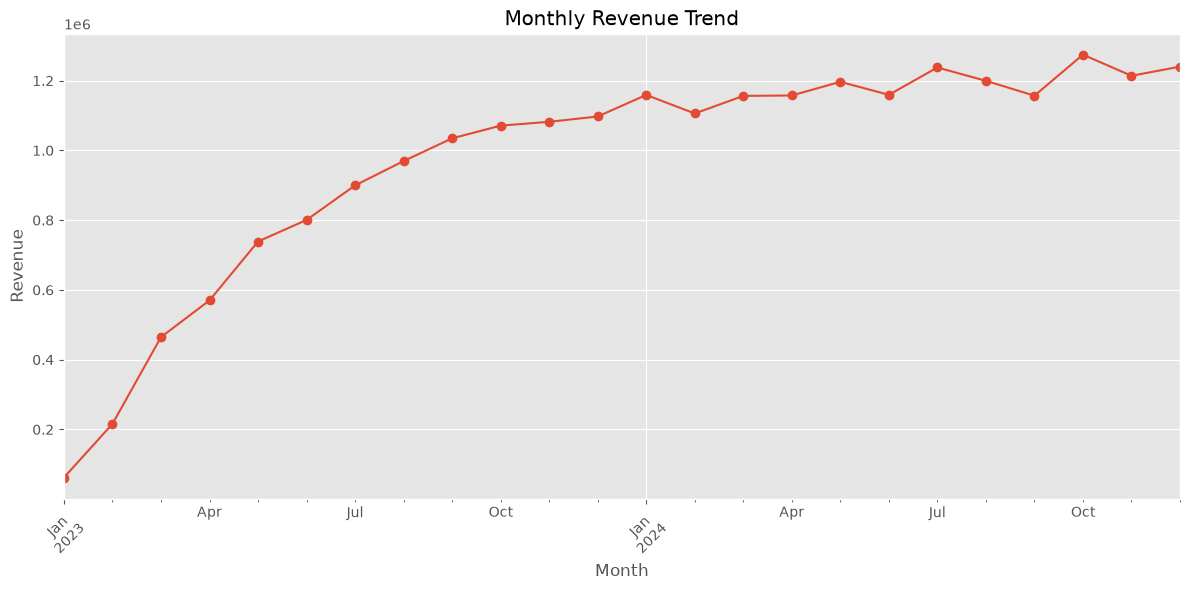

In [35]:
# Plot monthly revenue

plt.figure(figsize=(12, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [36]:
# Revenue by acquisition channel

channel_revenue = (
    df.groupby("acquisition_channel")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

channel_revenue

acquisition_channel
Instagram         3460426.96
Direct            3350333.47
Organic Search    3321020.31
Referral          3307095.45
Google Ads        3297271.96
Facebook Ads      3284639.73
Email             3241572.78
Name: revenue, dtype: float64

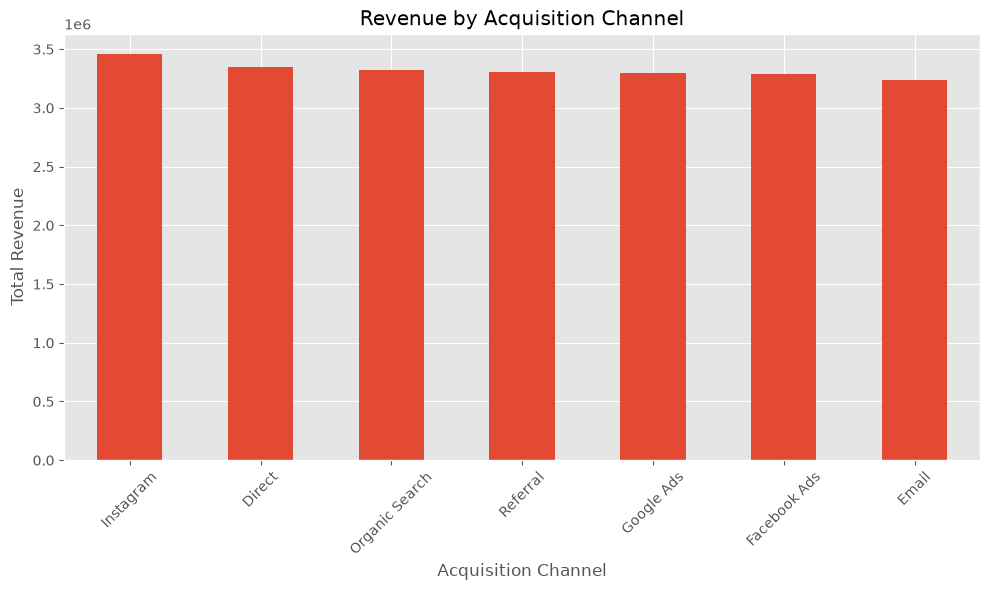

In [37]:
# Plot revenue by acquisition channel

plt.figure(figsize=(10, 6))

channel_revenue.plot(kind="bar")

plt.title("Revenue by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [38]:
# Number of orders by acquisition channel

channel_orders = (
    df.groupby("acquisition_channel")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

channel_orders

acquisition_channel
Instagram         10682
Direct            10312
Referral          10288
Organic Search    10245
Google Ads        10191
Facebook Ads      10115
Email              9939
Name: order_id, dtype: int64

In [39]:
# Calculate Average Order Value (AOV)

total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()

aov = total_revenue / total_orders

print("Average Order Value (AOV):", round(aov, 2))

Average Order Value (AOV): 324.11


In [40]:
# Determine each customer's first purchase date

first_purchase = (
    df.groupby("customer_id")["transaction_date"]
    .min()
    .reset_index()
)

first_purchase.columns = ["customer_id", "first_purchase_date"]

first_purchase.head()

,customer_id,first_purchase_date
0,CUST000001,2023-05-24
1,CUST000002,2024-03-18
2,CUST000003,2023-10-21
3,CUST000004,2023-04-25
4,CUST000005,2023-04-13


In [41]:
# Create cohort month

first_purchase["cohort_month"] = (
    first_purchase["first_purchase_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

first_purchase.head()

,customer_id,first_purchase_date,cohort_month
0,CUST000001,2023-05-24,2023-05-01
1,CUST000002,2024-03-18,2024-03-01
2,CUST000003,2023-10-21,2023-10-01
3,CUST000004,2023-04-25,2023-04-01
4,CUST000005,2023-04-13,2023-04-01


In [42]:
# Add cohort information to the main dataset

df = df.merge(
    first_purchase[["customer_id", "cohort_month"]],
    on="customer_id",
    how="left"
)

df.head()

,order_id,customer_id,transaction_date,product_category,quantity,unit_price,revenue,signup_date,acquisition_channel,country,calculated_revenue,revenue_difference,cohort_month
0,ORD0000001,CUST000001,2023-05-24,Fashion,4.0,144.98,579.92,2023-04-13,Instagram,Canada,579.92,0.0,2023-05-01
1,ORD0000002,CUST000002,2024-03-18,Beauty,3.0,28.21,84.63,2024-03-11,Email,USA,84.63,0.0,2024-03-01
2,ORD0000003,CUST000002,2024-04-09,Beauty,4.0,24.68,98.72,2024-03-11,Email,USA,98.72,0.0,2024-03-01
3,ORD0000004,CUST000002,2024-05-05,Fashion,2.0,35.77,71.54,2024-03-11,Email,USA,71.54,0.0,2024-03-01
4,ORD0000005,CUST000002,2024-06-20,Sports,2.0,19.67,39.34,2024-03-11,Email,USA,39.34,0.0,2024-03-01


In [43]:
# Create transaction month

df["transaction_month"] = (
    df["transaction_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

df[["customer_id", "transaction_date", "transaction_month", "cohort_month"]].head()

,customer_id,transaction_date,transaction_month,cohort_month
0,CUST000001,2023-05-24,2023-05-01,2023-05-01
1,CUST000002,2024-03-18,2024-03-01,2024-03-01
2,CUST000002,2024-04-09,2024-04-01,2024-03-01
3,CUST000002,2024-05-05,2024-05-01,2024-03-01
4,CUST000002,2024-06-20,2024-06-01,2024-03-01


In [44]:
# Calculate months since customer acquisition

df["cohort_index"] = (
    (df["transaction_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["transaction_month"].dt.month - df["cohort_month"].dt.month)
)

# Check the result
df[
    [
        "customer_id",
        "cohort_month",
        "transaction_month",
        "cohort_index"
    ]
].head(10)

,customer_id,cohort_month,transaction_month,cohort_index
0,CUST000001,2023-05-01,2023-05-01,0.0
1,CUST000002,2024-03-01,2024-03-01,0.0
2,CUST000002,2024-03-01,2024-04-01,1.0
3,CUST000002,2024-03-01,2024-05-01,2.0
4,CUST000002,2024-03-01,2024-06-01,3.0
5,CUST000002,2024-03-01,2024-07-01,4.0
6,CUST000002,2024-03-01,2024-08-01,5.0
7,CUST000002,2024-03-01,2024-10-01,7.0
8,CUST000003,2023-10-01,2023-10-01,0.0
9,CUST000004,2023-04-01,2023-04-01,0.0


In [45]:
# Check cohort index values

print("Minimum cohort index:", df["cohort_index"].min())
print("Maximum cohort index:", df["cohort_index"].max())

print("\nCohort index distribution:")
print(df["cohort_index"].value_counts().sort_index())

Minimum cohort index: 0.0
Maximum cohort index: 22.0

Cohort index distribution:
cohort_index
0.0     21847
1.0     10423
2.0     10001
3.0      7355
4.0      5595
5.0      4249
6.0      3174
7.0      2415
8.0      1830
9.0      1379
10.0     1007
11.0      743
12.0      521
13.0      400
14.0      270
15.0      183
16.0      153
17.0       98
18.0       60
19.0       35
20.0       22
21.0        8
22.0        4
Name: count, dtype: int64


In [46]:
# Calculate customers in each cohort

cohort_size = (
    df.groupby("cohort_month")["customer_id"]
    .nunique()
    .reset_index()
)

cohort_size.columns = ["cohort_month", "cohort_customers"]

cohort_size

,cohort_month,cohort_customers
0,2023-01-01,159
1,2023-02-01,541
2,2023-03-01,851
3,2023-04-01,797
4,2023-05-01,888
5,2023-06-01,791
6,2023-07-01,886
7,2023-08-01,837
8,2023-09-01,851
9,2023-10-01,833


In [47]:
# Calculate retained customers

cohort_retention = (
    df.groupby(
        ["cohort_month", "cohort_index"]
    )["customer_id"]
    .nunique()
    .reset_index()
)

cohort_retention.columns = [
    "cohort_month",
    "cohort_index",
    "retained_customers"
]

cohort_retention.head(20)

,cohort_month,cohort_index,retained_customers
0,2023-01-01,0.0,159
1,2023-01-01,1.0,69
2,2023-01-01,2.0,83
3,2023-01-01,3.0,57
4,2023-01-01,4.0,52
5,2023-01-01,5.0,36
6,2023-01-01,6.0,41
7,2023-01-01,7.0,28
8,2023-01-01,8.0,24
9,2023-01-01,9.0,21


In [48]:
# Create cohort retention matrix

retention_matrix = cohort_retention.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="retained_customers"
)

retention_matrix

cohort_index,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0
cohort_month,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01,159.0,69.0,83.0,57.0,52.0,36.0,41.0,28.0,24.0,21.0,11.0,10.0,5.0,4.0,3.0,2.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN
2023-02-01,541.0,277.0,238.0,216.0,156.0,134.0,104.0,73.0,69.0,60.0,46.0,29.0,25.0,17.0,10.0,13.0,8.0,8.0,4.0,4.0,4.0,2.0,3.0
2023-03-01,851.0,411.0,409.0,317.0,251.0,194.0,140.0,121.0,83.0,70.0,56.0,40.0,38.0,31.0,23.0,15.0,15.0,11.0,7.0,9.0,5.0,5.0,NaN
2023-04-01,797.0,406.0,382.0,306.0,253.0,194.0,156.0,126.0,96.0,81.0,59.0,53.0,39.0,29.0,31.0,27.0,19.0,16.0,13.0,10.0,9.0,NaN,NaN
2023-05-01,888.0,451.0,425.0,317.0,265.0,215.0,158.0,138.0,111.0,73.0,73.0,49.0,45.0,34.0,28.0,18.0,17.0,15.0,10.0,9.0,NaN,NaN,NaN
2023-06-01,791.0,380.0,391.0,277.0,228.0,182.0,156.0,128.0,110.0,86.0,66.0,50.0,38.0,42.0,25.0,26.0,16.0,17.0,16.0,NaN,NaN,NaN,NaN
2023-07-01,886.0,425.0,443.0,300.0,249.0,211.0,160.0,117.0,93.0,87.0,67.0,60.0,38.0,43.0,28.0,22.0,30.0,16.0,NaN,NaN,NaN,NaN,NaN
2023-08-01,837.0,430.0,427.0,352.0,267.0,210.0,183.0,141.0,114.0,94.0,78.0,43.0,42.0,31.0,26.0,24.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01,851.0,439.0,390.0,332.0,264.0,197.0,172.0,132.0,110.0,74.0,81.0,61.0,44.0,36.0,27.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# Calculate retention percentage

retention_percentage = retention_matrix.divide(
    retention_matrix[0],
    axis=0
) * 100

retention_percentage.round(2)

cohort_index,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0
cohort_month,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01,100.0,43.40,52.20,35.85,32.70,22.64,25.79,17.61,15.09,13.21,6.92,6.29,3.14,2.52,1.89,1.26,1.26,1.26,0.63,NaN,NaN,NaN,NaN
2023-02-01,100.0,51.20,43.99,39.93,28.84,24.77,19.22,13.49,12.75,11.09,8.50,5.36,4.62,3.14,1.85,2.40,1.48,1.48,0.74,0.74,0.74,0.37,0.55
2023-03-01,100.0,48.30,48.06,37.25,29.49,22.80,16.45,14.22,9.75,8.23,6.58,4.70,4.47,3.64,2.70,1.76,1.76,1.29,0.82,1.06,0.59,0.59,NaN
2023-04-01,100.0,50.94,47.93,38.39,31.74,24.34,19.57,15.81,12.05,10.16,7.40,6.65,4.89,3.64,3.89,3.39,2.38,2.01,1.63,1.25,1.13,NaN,NaN
2023-05-01,100.0,50.79,47.86,35.70,29.84,24.21,17.79,15.54,12.50,8.22,8.22,5.52,5.07,3.83,3.15,2.03,1.91,1.69,1.13,1.01,NaN,NaN,NaN
2023-06-01,100.0,48.04,49.43,35.02,28.82,23.01,19.72,16.18,13.91,10.87,8.34,6.32,4.80,5.31,3.16,3.29,2.02,2.15,2.02,NaN,NaN,NaN,NaN
2023-07-01,100.0,47.97,50.00,33.86,28.10,23.81,18.06,13.21,10.50,9.82,7.56,6.77,4.29,4.85,3.16,2.48,3.39,1.81,NaN,NaN,NaN,NaN,NaN
2023-08-01,100.0,51.37,51.02,42.05,31.90,25.09,21.86,16.85,13.62,11.23,9.32,5.14,5.02,3.70,3.11,2.87,2.51,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01,100.0,51.59,45.83,39.01,31.02,23.15,20.21,15.51,12.93,8.70,9.52,7.17,5.17,4.23,3.17,2.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN


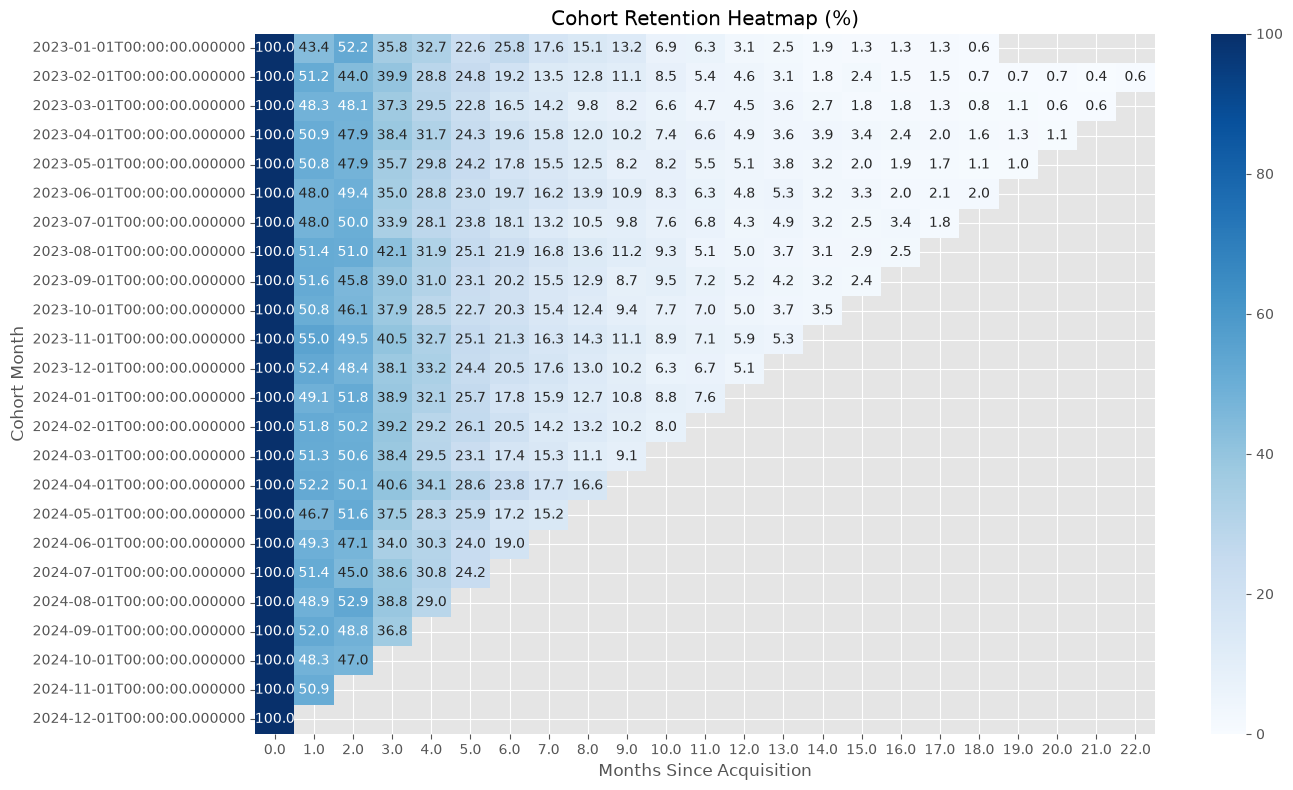

In [50]:
# Create Cohort Retention Heatmap

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title("Cohort Retention Heatmap (%)")
plt.xlabel("Months Since Acquisition")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

## Cohort Retention Analysis

Customers are grouped into cohorts based on the month of their first transaction. The cohort retention matrix measures the percentage of customers from each cohort who remain active in subsequent months.

Month 0 represents the customer's initial acquisition month and is used as the 100% baseline. Retention percentages in later months show how customer activity changes over time.

The retention heatmap helps identify customer churn patterns and compare retention performance across different acquisition cohorts.

In [51]:
# Create customer-level CLTV dataset

customer_cltv = df.groupby("customer_id").agg(
    total_revenue=("revenue", "sum"),
    total_orders=("order_id", "nunique"),
    total_quantity=("quantity", "sum"),
    first_purchase=("transaction_date", "min"),
    last_purchase=("transaction_date", "max")
).reset_index()

customer_cltv.head()

,customer_id,total_revenue,total_orders,total_quantity,first_purchase,last_purchase
0,CUST000001,579.92,1,4.0,2023-05-24,2023-05-24
1,CUST000002,1472.17,7,18.0,2024-03-18,2024-10-12
2,CUST000003,359.76,1,3.0,2023-10-21,2023-10-21
3,CUST000004,1633.92,8,17.0,2023-04-25,2023-12-04
4,CUST000005,209.94,2,3.0,2023-04-13,2023-06-02


In [52]:
# Calculate customer lifespan in days

customer_cltv["lifespan_days"] = (
    customer_cltv["last_purchase"]
    - customer_cltv["first_purchase"]
).dt.days

customer_cltv.head()

,customer_id,total_revenue,total_orders,total_quantity,first_purchase,last_purchase,lifespan_days
0,CUST000001,579.92,1,4.0,2023-05-24,2023-05-24,0
1,CUST000002,1472.17,7,18.0,2024-03-18,2024-10-12,208
2,CUST000003,359.76,1,3.0,2023-10-21,2023-10-21,0
3,CUST000004,1633.92,8,17.0,2023-04-25,2023-12-04,223
4,CUST000005,209.94,2,3.0,2023-04-13,2023-06-02,50


In [54]:
# Check customer lifespan statistics

customer_cltv["lifespan_days"].describe()

count    19076.000000
mean        89.800430
std        103.128078
min          0.000000
25%          0.000000
50%         56.000000
75%        134.000000
max        684.000000
Name: lifespan_days, dtype: float64

In [55]:
# Calculate Average Order Value per customer

customer_cltv["average_order_value"] = (
    customer_cltv["total_revenue"]
    / customer_cltv["total_orders"]
)

customer_cltv.head()

,customer_id,total_revenue,total_orders,total_quantity,first_purchase,last_purchase,lifespan_days,average_order_value
0,CUST000001,579.92,1,4.0,2023-05-24,2023-05-24,0,579.92
1,CUST000002,1472.17,7,18.0,2024-03-18,2024-10-12,208,210.31
2,CUST000003,359.76,1,3.0,2023-10-21,2023-10-21,0,359.76
3,CUST000004,1633.92,8,17.0,2023-04-25,2023-12-04,223,204.24
4,CUST000005,209.94,2,3.0,2023-04-13,2023-06-02,50,104.97


In [56]:
# Calculate purchase frequency

customer_cltv["purchase_frequency"] = (
    customer_cltv["total_orders"]
    / (
        customer_cltv["lifespan_days"].replace(0, 1)
        / 30
    )
)

customer_cltv.head()

,customer_id,total_revenue,total_orders,total_quantity,first_purchase,last_purchase,lifespan_days,average_order_value,purchase_frequency
0,CUST000001,579.92,1,4.0,2023-05-24,2023-05-24,0,579.92,30.000000
1,CUST000002,1472.17,7,18.0,2024-03-18,2024-10-12,208,210.31,1.009615
2,CUST000003,359.76,1,3.0,2023-10-21,2023-10-21,0,359.76,30.000000
3,CUST000004,1633.92,8,17.0,2023-04-25,2023-12-04,223,204.24,1.076233
4,CUST000005,209.94,2,3.0,2023-04-13,2023-06-02,50,104.97,1.200000


In [57]:
# Calculate historical CLTV

customer_cltv["cltv"] = (
    customer_cltv["average_order_value"]
    * customer_cltv["purchase_frequency"]
    * (customer_cltv["lifespan_days"] / 30)
)

customer_cltv.head()

,customer_id,total_revenue,total_orders,total_quantity,first_purchase,last_purchase,lifespan_days,average_order_value,purchase_frequency,cltv
0,CUST000001,579.92,1,4.0,2023-05-24,2023-05-24,0,579.92,30.000000,0.00
1,CUST000002,1472.17,7,18.0,2024-03-18,2024-10-12,208,210.31,1.009615,1472.17
2,CUST000003,359.76,1,3.0,2023-10-21,2023-10-21,0,359.76,30.000000,0.00
3,CUST000004,1633.92,8,17.0,2023-04-25,2023-12-04,223,204.24,1.076233,1633.92
4,CUST000005,209.94,2,3.0,2023-04-13,2023-06-02,50,104.97,1.200000,209.94


In [58]:
# CLTV summary statistics

customer_cltv["cltv"].describe()

count    19076.000000
mean      1135.077991
std       1170.774767
min          0.000000
25%          0.000000
50%        881.455000
75%       1691.910000
max       8434.190000
Name: cltv, dtype: float64

In [59]:
# Top 10 customers by CLTV

top_cltv_customers = (
    customer_cltv
    .sort_values("cltv", ascending=False)
    .head(10)
)

top_cltv_customers[
    [
        "customer_id",
        "total_revenue",
        "total_orders",
        "lifespan_days",
        "cltv"
    ]
]

,customer_id,total_revenue,total_orders,lifespan_days,cltv
1093,CUST001138,8434.19,22,658,8434.19
4491,CUST004686,8270.33,19,501,8270.33
549,CUST000574,8171.62,14,481,8171.62
14352,CUST015048,8098.60,21,596,8098.60
11977,CUST012566,7981.00,22,684,7981.00
17384,CUST018229,7784.44,20,558,7784.44
15584,CUST016337,7663.86,16,508,7663.86
13923,CUST014597,7608.72,20,508,7608.72
17550,CUST018402,7545.79,20,576,7545.79
12203,CUST012799,7529.75,18,517,7529.75


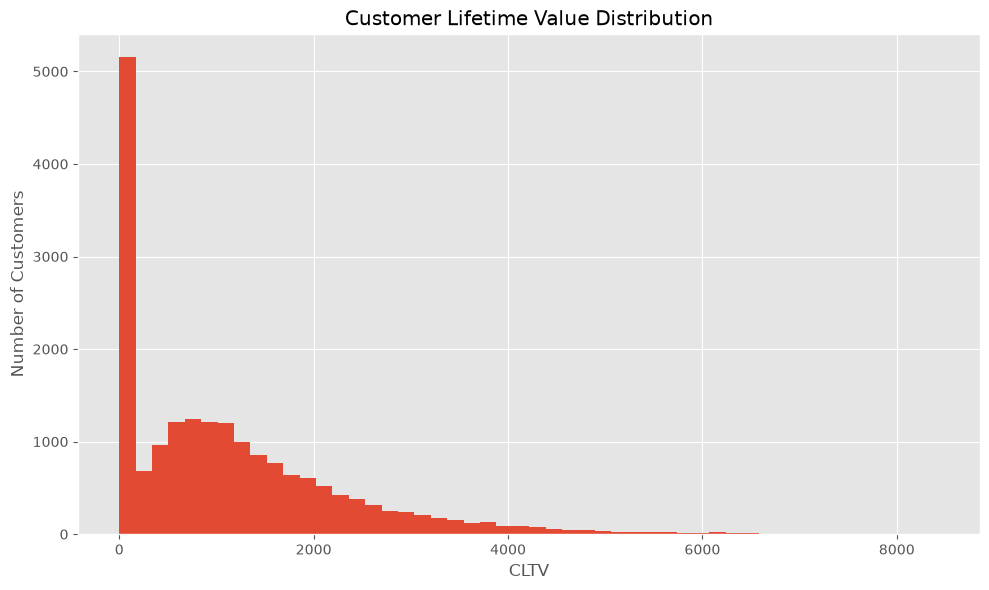

In [60]:
# Check CLTV distribution

plt.figure(figsize=(10, 6))

plt.hist(customer_cltv["cltv"], bins=50)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("CLTV")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [61]:
# Top 10 customers by CLTV

customer_cltv[
    [
        "customer_id",
        "total_revenue",
        "total_orders",
        "lifespan_days",
        "average_order_value",
        "purchase_frequency",
        "cltv"
    ]
].sort_values(
    "cltv",
    ascending=False
).head(10)

,customer_id,total_revenue,total_orders,lifespan_days,average_order_value,purchase_frequency,cltv
1093,CUST001138,8434.19,22,658,383.372273,1.003040,8434.19
4491,CUST004686,8270.33,19,501,435.280526,1.137725,8270.33
549,CUST000574,8171.62,14,481,583.687143,0.873181,8171.62
14352,CUST015048,8098.60,21,596,385.647619,1.057047,8098.60
11977,CUST012566,7981.00,22,684,362.772727,0.964912,7981.00
17384,CUST018229,7784.44,20,558,389.222000,1.075269,7784.44
15584,CUST016337,7663.86,16,508,478.991250,0.944882,7663.86
13923,CUST014597,7608.72,20,508,380.436000,1.181102,7608.72
17550,CUST018402,7545.79,20,576,377.289500,1.041667,7545.79
12203,CUST012799,7529.75,18,517,418.319444,1.044487,7529.75


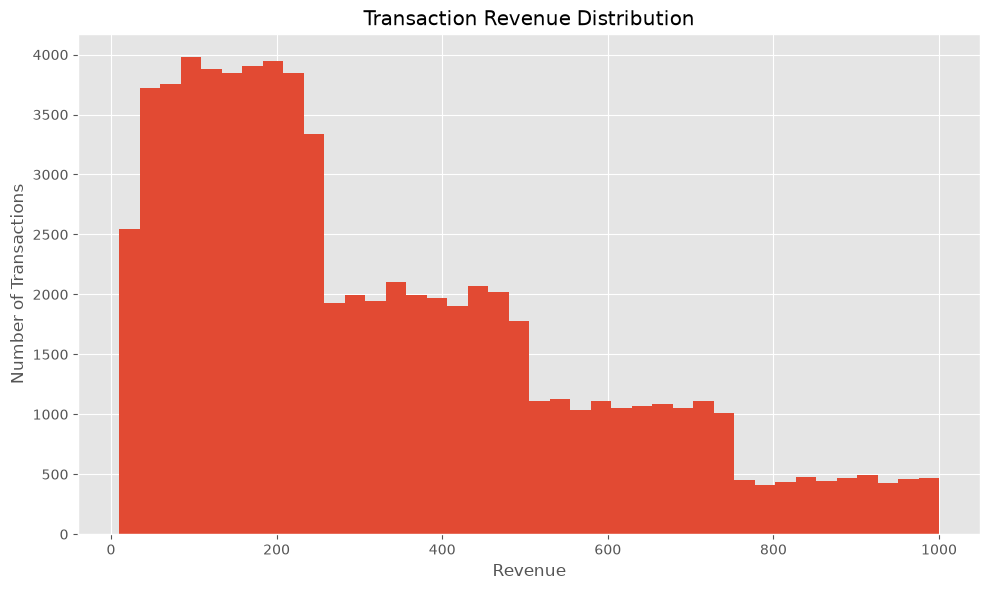

In [63]:
# Revenue distribution

plt.figure(figsize=(10, 6))

plt.hist(df["revenue"], bins=40)

plt.title("Transaction Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

## Customer Lifetime Value (CLTV)

Customer-level CLTV was calculated using historical transaction behavior. The analysis considers average order value, purchase frequency, and customer lifespan to estimate the value generated by each customer.

The CLTV distribution helps identify high-value customers and understand the variation in customer value across the customer base.

This historical CLTV analysis provides the foundation for developing a predictive 12-month CLTV model in the next stage.